In [7]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ihelon/coffee-sales")

print(f"Dataset terunduh di: {path}")

files = os.listdir(path)
print(f"Daftar file: {files}")


if "index.csv" in files:
    df = pd.read_csv(os.path.join(path, "index.csv"))
    print("\n--- Berhasil Load Data ---")
    print(df.head())
else:
    print("\nFile index.csv tidak ditemukan, cari lagi yaw >_<")

/home/rima/Documents/DS/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset terunduh di: /home/rima/.cache/kagglehub/datasets/ihelon/coffee-sales/versions/21
Daftar file: ['index_2.csv', 'index_1.csv']

File index.csv tidak ditemukan, cari lagi yaw >_<


In [8]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("ihelon/coffee-sales")

path_1 = os.path.join(path, "index_1.csv")
path_2 = os.path.join(path, "index_2.csv")

df1 = pd.read_csv(path_1)
df2 = pd.read_csv(path_2)

#MENGGABUNGKAN DATA
df = pd.concat([df1, df2], ignore_index=True)

print(f"Data 1: {len(df1)} baris")
print(f"Data 2: {len(df2)} baris")
print(f"Total setelah digabung: {len(df)} baris")

# Tampilkan 5 baris pertama
print(df.head())

Data 1: 3636 baris
Data 2: 262 baris
Total setelah digabung: 3898 baris
         date                 datetime cash_type                 card  money  \
0  2024-03-01  2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1  2024-03-01  2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2  2024-03-01  2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   
3  2024-03-01  2024-03-01 13:46:33.006      card  ANON-0000-0000-0003   28.9   
4  2024-03-01  2024-03-01 13:48:14.626      card  ANON-0000-0000-0004   38.7   

     coffee_name  
0          Latte  
1  Hot Chocolate  
2  Hot Chocolate  
3      Americano  
4          Latte  


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Cek missing value 
print("Cek null:")
print(df.isnull().sum())

print("\nAda null atau tidak:")
print(df.isnull().any())

print("\nTotal semua null:")
print(df.isnull().sum().sum())


Cek null:
date             0
datetime         0
cash_type        0
card           351
money            0
coffee_name      0
dtype: int64

Ada null atau tidak:
date           False
datetime       False
cash_type      False
card            True
money          False
coffee_name    False
dtype: bool

Total semua null:
351


In [10]:
df_clean = df.dropna(subset=['coffee_name', 'cash_type'])

# Kolom numerik → isi dengan rata-rata 
mean_money = df_clean['money'].mean()
df_clean['money'] = df_clean['money'].fillna(mean_money)

# Kolom tambahan 
df_clean['card'] = df_clean['card'].fillna('N/A')

print("\nSetelah penanganan null:")
print(df_clean.isnull().sum())



Setelah penanganan null:
date           0
datetime       0
cash_type      0
card           0
money          0
coffee_name    0
dtype: int64


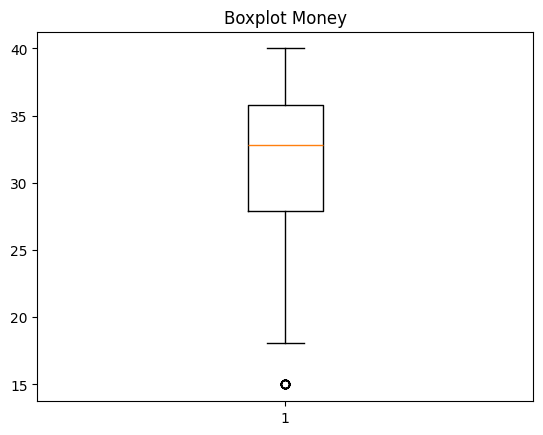

In [11]:
plt.boxplot(df_clean['money'])
plt.title("Boxplot Money")
plt.show()

# Hitung IQR
Q1 = df_clean['money'].quantile(0.25)
Q3 = df_clean['money'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

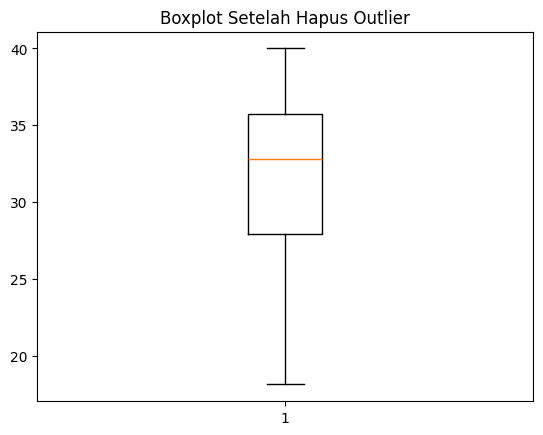

In [12]:
outlier_index = df_clean[
    (df_clean['money'] < lower) | 
    (df_clean['money'] > upper)
].index

# Hapus data outlier
df_final = df_clean.drop(outlier_index)

# boxplot setelah dibersihkan
plt.boxplot(df_final['money'])
plt.title("Boxplot Setelah Hapus Outlier")
plt.show()

In [13]:
print("\nJumlah data awal:", len(df))
print("Setelah cleaning:", len(df_final))


Jumlah data awal: 3898
Setelah cleaning: 3882


In [14]:
import numpy as np

# ambil kolom money dan hilangkan yang kosong
uang = df['money'].dropna()

stats_uang = {
    'jumlah_data': len(uang),
    'min': uang.min(),
    'max': uang.max(),
    'mean': uang.mean(),
    'rentang': uang.max() - uang.min(),
    'median': np.median(uang),
    'std': uang.std(ddof=1),
    'var': uang.var(ddof=1)
}

print("\nStatistik Deskriptif untuk kolom 'money':")
for k, v in stats_uang.items():
    print(f"{k}: {v}")


Statistik Deskriptif untuk kolom 'money':
jumlah_data: 3898
min: 15.0
max: 40.0
mean: 31.380600307850177
rentang: 25.0
median: 32.82
std: 5.064609884870963
var: 25.65027328593267


In [15]:
df.describe()

,money
count,3898.00000
mean,31.38060
std,5.06461
min,15.00000
25%,27.92000
50%,32.82000
75%,35.76000
max,40.00000


Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'], dtype='str')


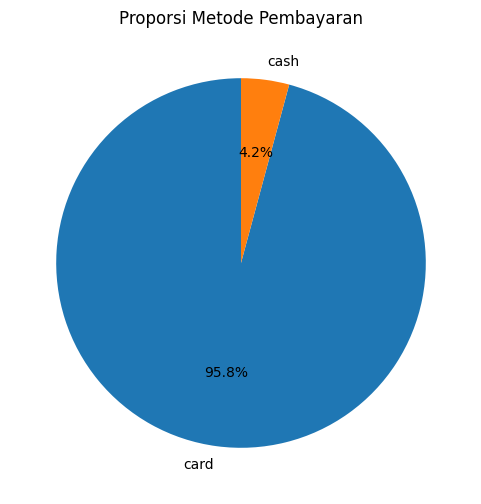

In [16]:
# Pastikan kolom ada
print(df_final.columns)

# Hitung jumlah metode pembayaran
payment_counts = df_final['cash_type'].value_counts()

# Plot pie chart
payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6,6)
)

plt.title('Proporsi Metode Pembayaran')
plt.ylabel('')
plt.show()

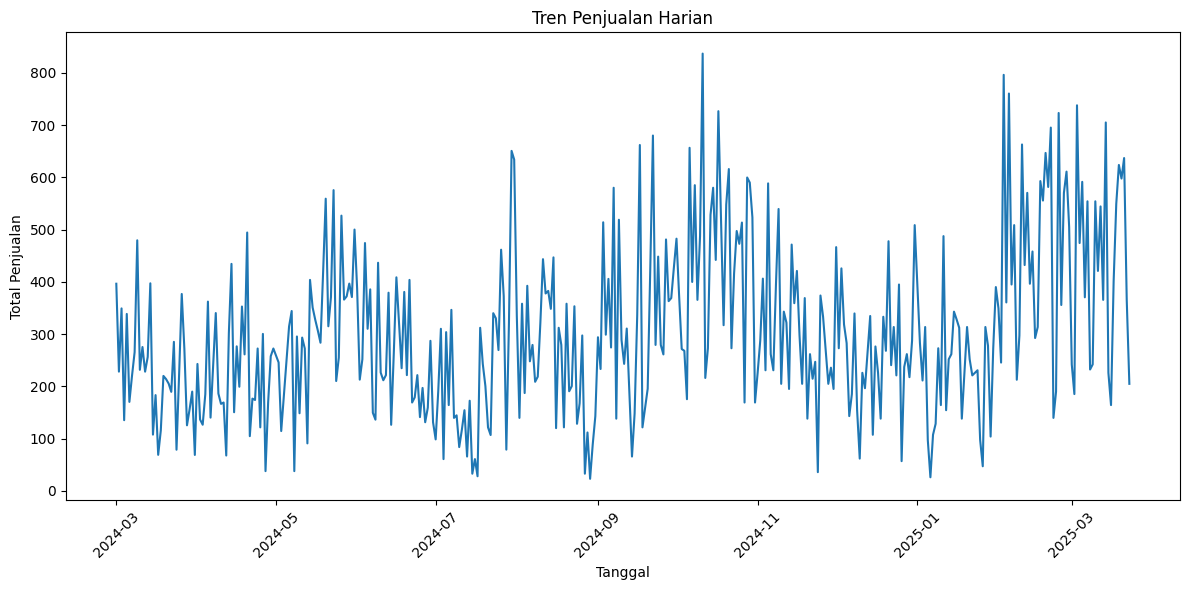

In [21]:
df_final['datetime'] = pd.to_datetime(df_final['datetime'], errors='coerce')

# Buat kolom tanggal (tanpa jam)
df_final['date'] = df_final['datetime'].dt.date

# Agregasi total penjualan per hari
daily_sales = df_final.groupby('date')['money'].sum()

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Tren Penjualan Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

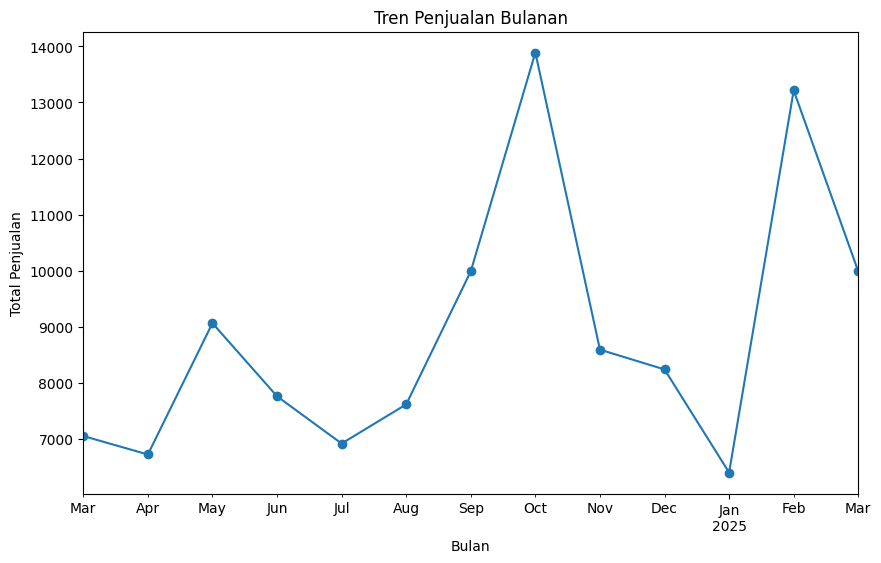

In [22]:
df_final['month'] = df_final['datetime'].dt.to_period('M')

monthly_sales = df_final.groupby('month')['money'].sum()

monthly_sales.plot(figsize=(10,6), marker='o')
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Penjualan')
plt.show()

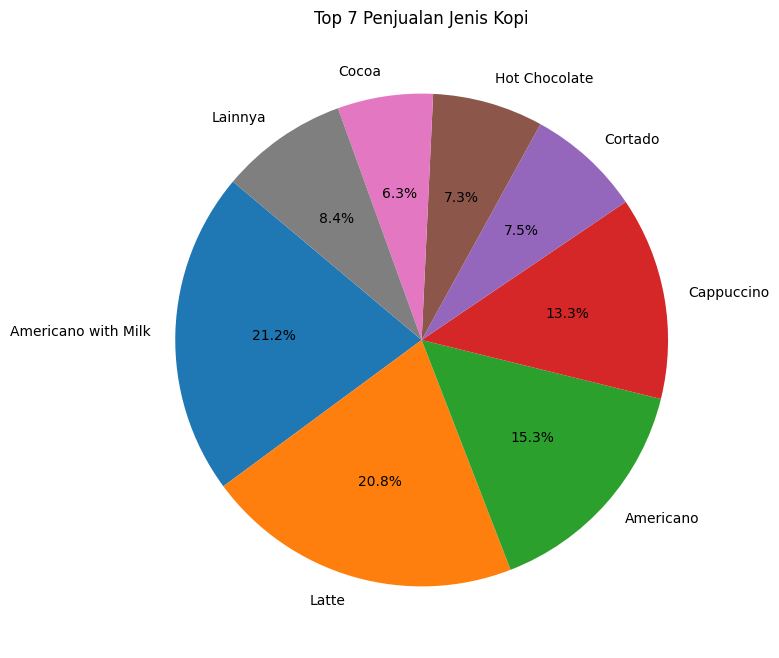

In [19]:
top_coffee = coffee_counts.head(7)
others = pd.Series([coffee_counts.iloc[7:].sum()], index=['Lainnya'])
coffee_final_counts = pd.concat([top_coffee, others])

plt.figure(figsize=(8, 8))
coffee_final_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    title='Top 7 Penjualan Jenis Kopi'
)

plt.ylabel('')
plt.show()

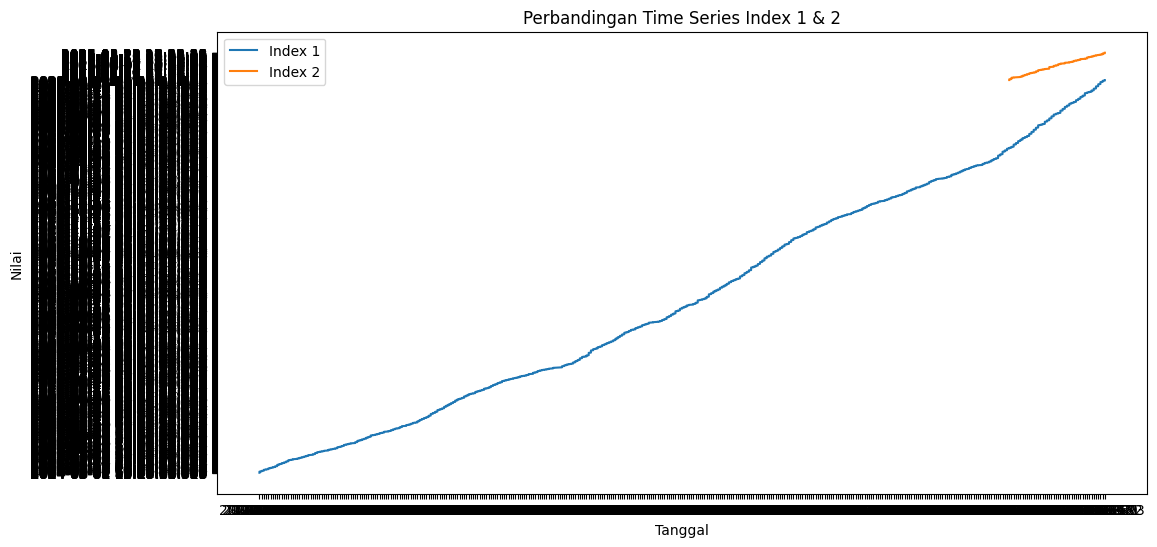

In [24]:
#ntar ini dihapus gpp
plt.figure(figsize=(12,6))

plt.plot(df1['date'], df1.iloc[:,1], label='Index 1')
plt.plot(df2['date'], df2.iloc[:,1], label='Index 2')

plt.title('Perbandingan Time Series Index 1 & 2')
plt.xlabel('Tanggal')
plt.ylabel('Nilai')
plt.legend()
plt.show()

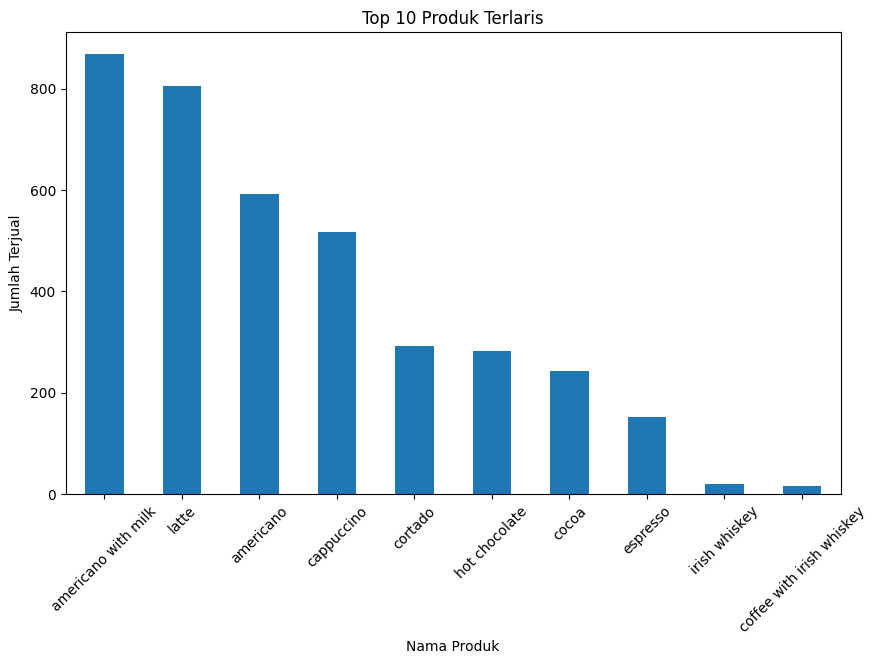

In [33]:
df_final['coffee_name'] = df_final['coffee_name'].str.strip()   # hapus spasi
df_final['coffee_name'] = df_final['coffee_name'].str.lower()   # samakan huruf kecil
top_products = df_final['coffee_name'].value_counts().head(10)

top_products.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Produk Terlaris')
plt.xlabel('Nama Produk')
plt.ylabel('Jumlah Terjual')
plt.xticks(rotation=45)
plt.show()

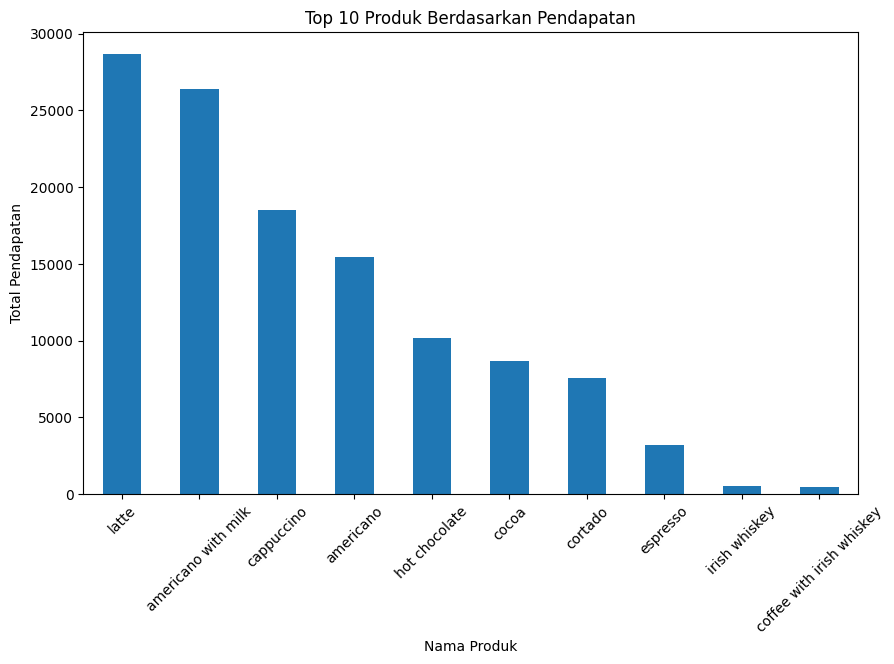

In [32]:
df_final['coffee_name'] = df_final['coffee_name'].str.strip()   # hapus spasi
df_final['coffee_name'] = df_final['coffee_name'].str.lower()   # samakan huruf kecil
revenue_per_product = df_final.groupby('coffee_name')['money'].sum().sort_values(ascending=False).head(10)

revenue_per_product.plot(kind='bar', figsize=(10,6))
plt.title('Top 10 Produk Berdasarkan Pendapatan')
plt.xlabel('Nama Produk')
plt.ylabel('Total Pendapatan')
plt.xticks(rotation=45)
plt.show()

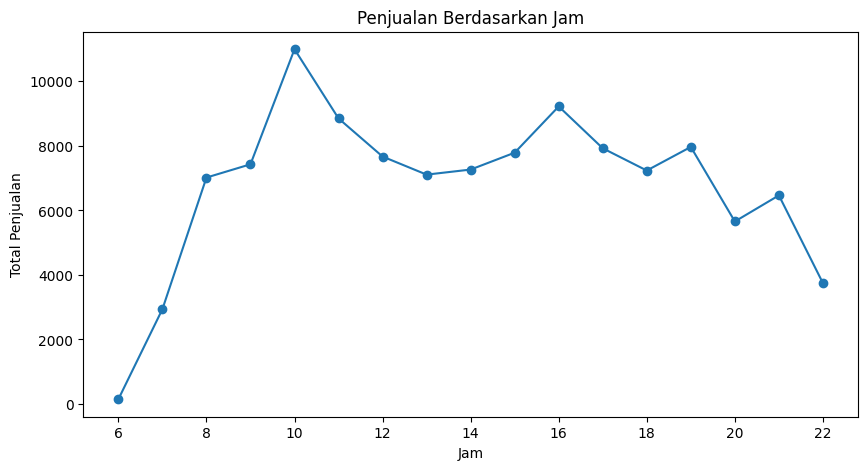

In [27]:
df_final['datetime'] = pd.to_datetime(df_final['datetime'])
df_final['hour'] = df_final['datetime'].dt.hour

hourly_sales = df_final.groupby('hour')['money'].sum()

hourly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Penjualan Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Total Penjualan')
plt.show()

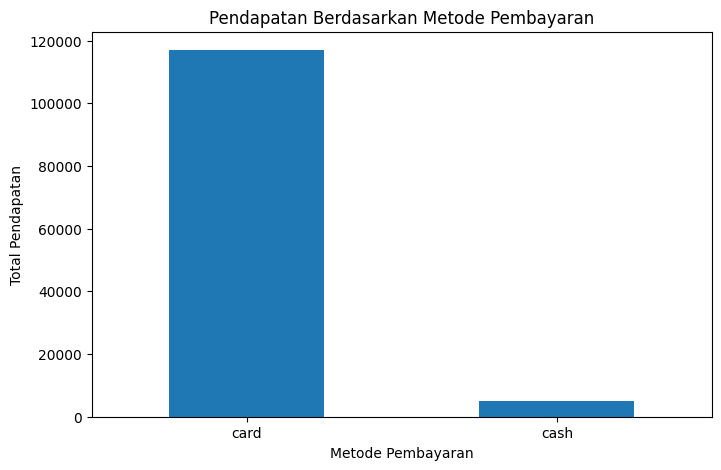

In [28]:
payment_revenue = df_final.groupby('cash_type')['money'].sum()

payment_revenue.plot(kind='bar', figsize=(8,5))
plt.title('Pendapatan Berdasarkan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Pendapatan')
plt.xticks(rotation=0)
plt.show()

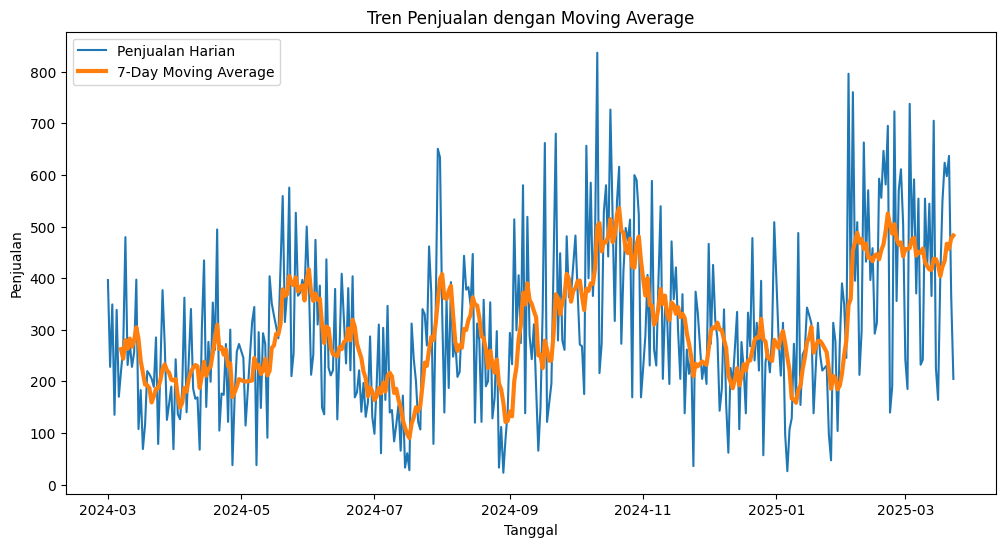

In [ ]:
#iki nko g usah dimasukne gpp (pro banget ki ketoke :))
df_final['date'] = df_final['datetime'].dt.date
daily_sales = df_final.groupby('date')['money'].sum()

rolling_avg = daily_sales.rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(daily_sales, label='Penjualan Harian')
plt.plot(rolling_avg, label='7-Day Moving Average', linewidth=3)

plt.title('Tren Penjualan dengan Moving Average')
plt.xlabel('Tanggal')
plt.ylabel('Penjualan')
plt.legend()
plt.show()

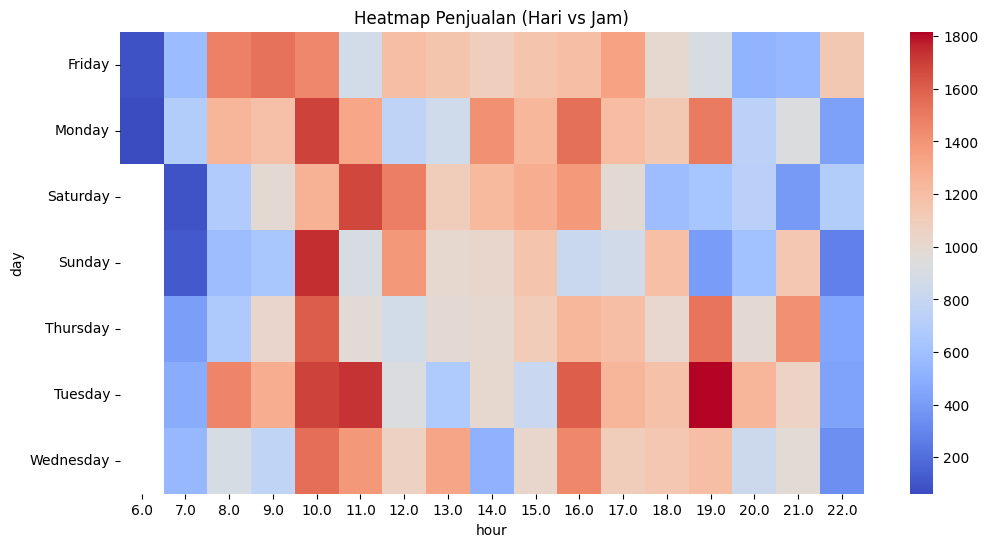

In [34]:
df_final['day'] = df_final['datetime'].dt.day_name()

pivot_table = df_final.pivot_table(
    values='money',
    index='day',
    columns='hour',
    aggfunc='sum'
)

import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title('Heatmap Penjualan (Hari vs Jam)')
plt.show()